# This is a sample Jupyter Notebook

Below is an example of a code cell. 
Put your cursor into the cell and press Shift+Enter to execute it and select the next one, or click 'Run Cell' button.

Press Double Shift to search everywhere for classes, files, tool windows, actions, and settings.

To learn more about Jupyter Notebooks in PyCharm, see [help](https://www.jetbrains.com/help/pycharm/ipython-notebook-support.html).
For an overview of PyCharm, go to Help -> Learn IDE features or refer to [our documentation](https://www.jetbrains.com/help/pycharm/getting-started.html).

ЭТАП 1: Загрузка данных
✓ Загружено записей: 161,076

ЭТАП 2: Преобразование WKT в геометрию
✓ Удалено записей с некорректной геометрией: 0
✓ Осталось записей: 161,076

ЭТАП 3: Создание GeoDataFrame и проецирование
✓ Создан GeoDataFrame с 161,076 объектами
✓ Исходная система координат: EPSG:4326
✓ Перепроецировано в EPSG:32635 (UTM zone 35N) за 0.30 сек
✓ Новая система координат: EPSG:32635

ЭТАП 4: Расчет площадей
✓ Площади рассчитаны
  - Минимальная площадь: 0.34 м²
  - Максимальная площадь: 72648.59 м²
  - Средняя площадь: 490.75 м²
  - Медианная площадь: 125.22 м²

ЭТАП 5: Фильтрация по площади
✓ Удалено объектов с площадью < 1.0 м²: 2
✓ Осталось объектов: 161,074

ЭТАП 6: Ремонт невалидной геометрии
✓ Найдено невалидных геометрий: 0 (0.00%)
  Ремонт геометрий...


  Прогресс: 0it [00:00, ?it/s]


✓ Осталось объектов после ремонта: 161,074
✓ Все геометрии валидны: True

ЭТАП 7: Статистическая фильтрация выбросов по площади
Статистика площадей:
  - Q1 (25-й перцентиль): 43.00 м²
  - Медиана (50-й перцентиль): 125.23 м²
  - Q3 (75-й перцентиль): 534.78 м²
  - IQR: 491.78 м²

Границы фильтрации:
  - Нижняя граница: 1.00 м²
  - Верхняя граница: 2010.10 м²

✓ Удалено объектов-выбросов: 6,771
✓ Осталось объектов: 154,303

ЭТАП 8: Оптимизация данных
  Упрощение геометрии...
  ✓ Упрощение завершено за 0.42 сек
  Создание пространственного индекса...
  ✓ Пространственный индекс создан за 0.07 сек

ЭТАП 9: Построение графа касаний
✓ Создан пустой граф
  Добавление 154,303 вершин...
✓ Добавлено 154,303 вершин

  Поиск касающихся полигонов...


  Обработка полигонов: 154403it [00:09, 15968.03it/s]                            



  Добавление 37,964 ребер в граф...
✓ Граф построен. Количество ребер: 37,964

ЭТАП 10: Анализ графа

Основные характеристики:
  - Количество вершин: 154,303
  - Количество ребер: 37,964

  Компоненты связности:
  - Количество компонент: 118,147
  - Размер компонент:
    * Минимальный: 1
    * Максимальный: 41
    * Медианный: 1
    * Средний: 1.31

  Степени вершин:
  - Минимальная степень: 0
  - Максимальная степень: 15
  - Средняя степень: 0.49
  - Медианная степень: 0

  Распределение степеней (топ-10):
    * Степень 0: 104,858 вершин (67.96%)
    * Степень 1: 34,532 вершин (22.38%)
    * Степень 2: 8,836 вершин (5.73%)
    * Степень 3: 3,347 вершин (2.17%)
    * Степень 4: 1,298 вершин (0.84%)
    * Степень 5: 686 вершин (0.44%)
    * Степень 6: 335 вершин (0.22%)
    * Степень 7: 291 вершин (0.19%)
    * Степень 8: 86 вершин (0.06%)
    * Степень 9: 27 вершин (0.02%)
    * Степень 10: 3 вершин (0.00%)

ЭТАП 11: Визуализация результатов


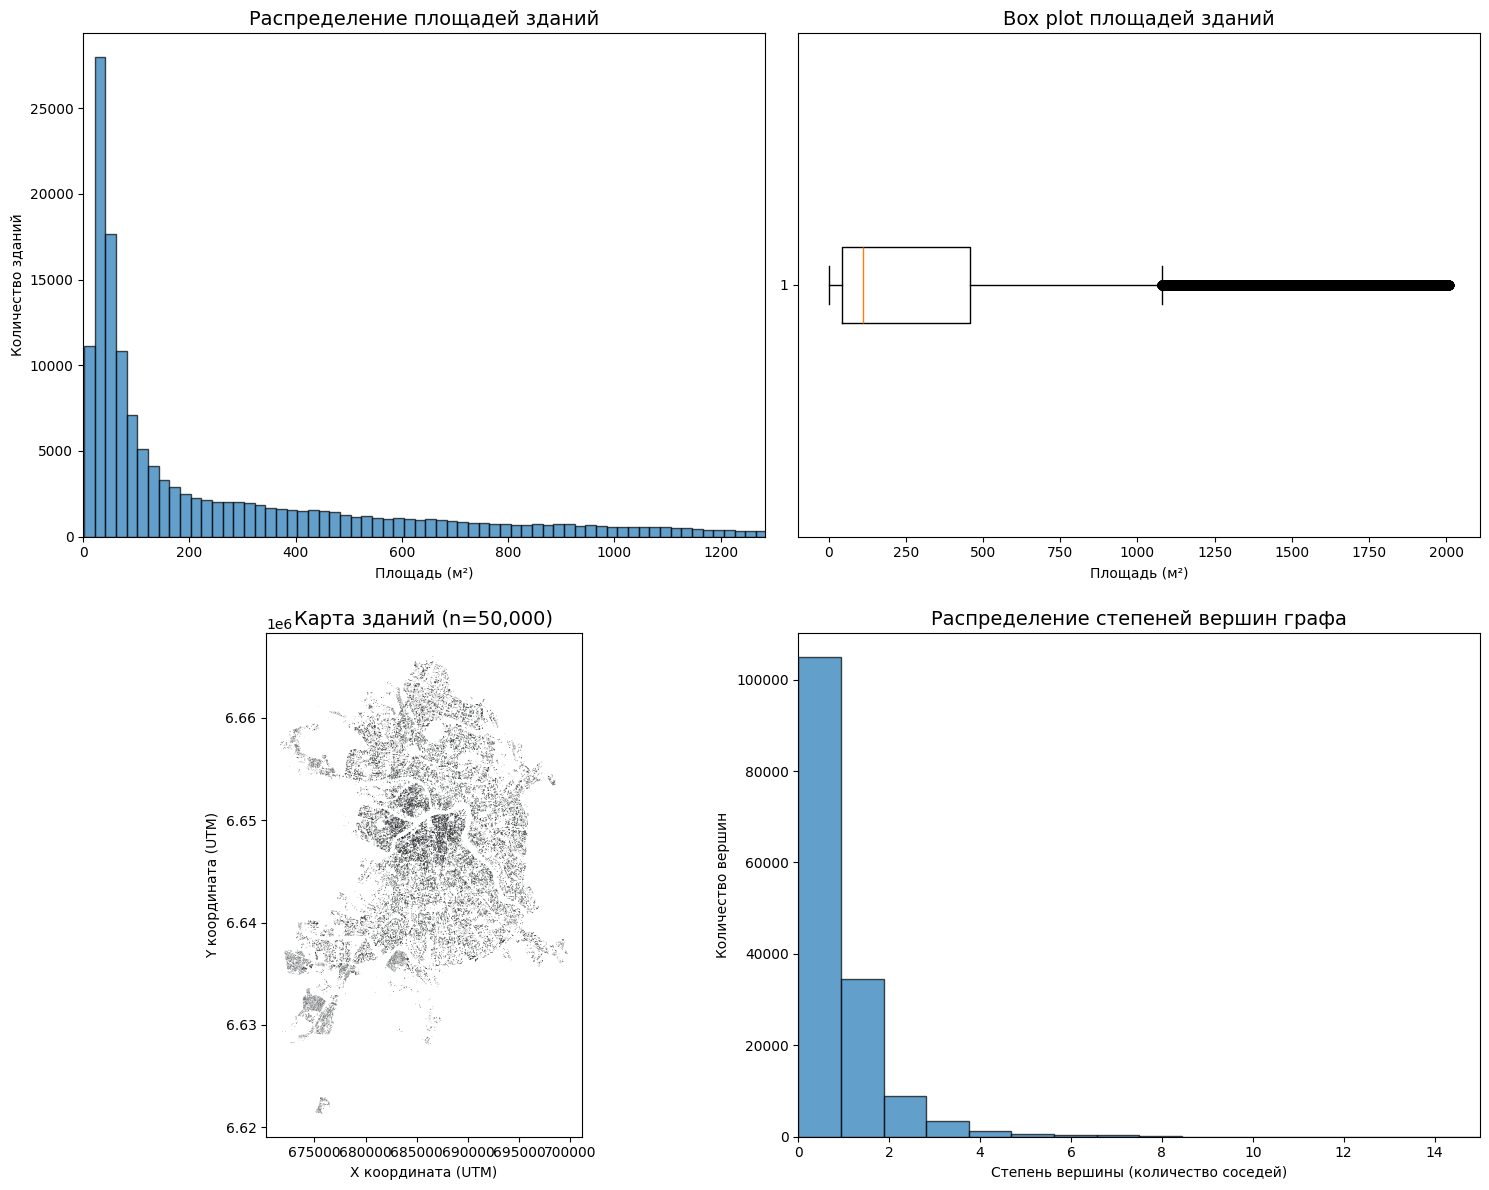


  Визуализация крупнейшей компоненты (41 вершин)...


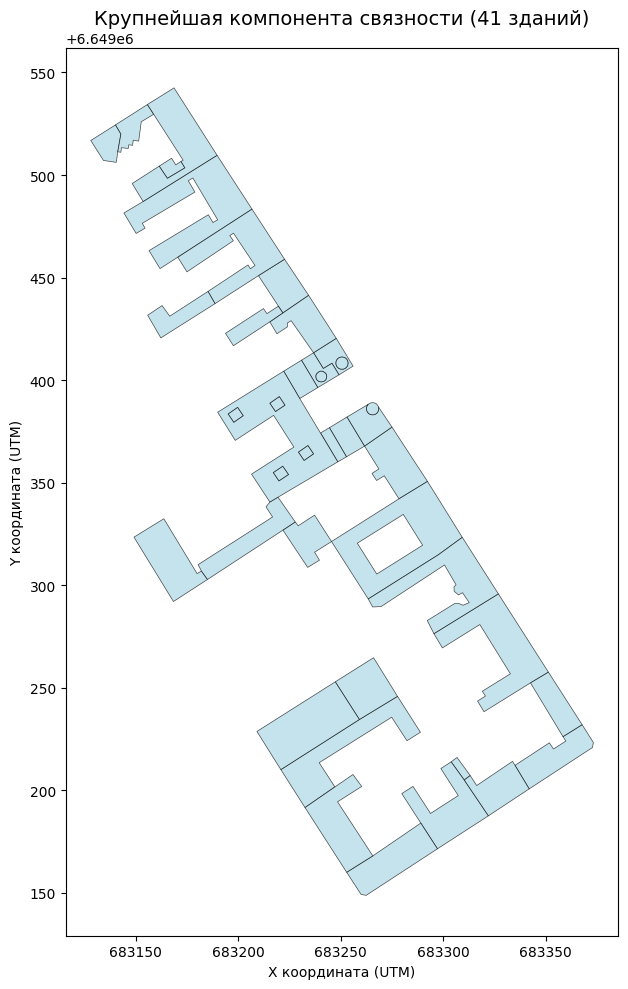


ИТОГОВАЯ СТАТИСТИКА ОБРАБОТКИ

Исходное количество записей: 161,076
Количество объектов после всех этапов очистки: 154,303
Удалено объектов (в процентах): 4.20%

Количество вершин в графе: 154,303
Количество ребер в графе: 37,964

ОБРАБОТКА ЗАВЕРШЕНА


In [8]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon, Point
from shapely.validation import make_valid
from shapely.strtree import STRtree
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import warnings
from tqdm import tqdm  # Для отображения прогресса
import time

warnings.filterwarnings('ignore')

# ============================================================================
# ЭТАП 1: ЗАГРУЗКА И ПРЕДВАРИТЕЛЬНАЯ ОБРАБОТКА ДАННЫХ
# ============================================================================
# Загружаем CSV файл. Указываем правильный разделитель и кодировку.
# low_memory=False гарантирует корректное определение типов данных.
print("=" * 80)
print("ЭТАП 1: Загрузка данных")
print("=" * 80)

file_path = 'cup_it_example_src_B.csv'
df = pd.read_csv(file_path, sep=',', encoding='utf-8', low_memory=False)
print(f"✓ Загружено записей: {len(df):,}")

# ============================================================================
# ЭТАП 2: ПРЕОБРАЗОВАНИЕ WKT В ГЕОМЕТРИЮ
# ============================================================================
# Функция для безопасного преобразования WKT в геометрию Shapely.
# Обрабатываем возможные ошибки в WKT строках.
print("\n" + "=" * 80)
print("ЭТАП 2: Преобразование WKT в геометрию")
print("=" * 80)

def safe_wkt_to_geometry(wkt_str):
    """
    Безопасное преобразование WKT строки в геометрию Shapely.
    Возвращает None в случае ошибки или пустой строки.
    """
    if not isinstance(wkt_str, str) or not wkt_str.strip():
        return None
    try:
        # Используем geopandas для преобразования, так как она более устойчива к разным форматам
        geom = gpd.GeoSeries.from_wkt([wkt_str])[0]
        # Проверяем, что геометрия не пустая и имеет корректный тип
        if geom is not None and not geom.is_empty:
            return geom
        return None
    except Exception as e:
        return None

# Применяем преобразование
df['geometry'] = df['wkt'].apply(safe_wkt_to_geometry)
# Удаляем записи с некорректной геометрией
initial_count = len(df)
df = df.dropna(subset=['geometry'])
print(f"✓ Удалено записей с некорректной геометрией: {initial_count - len(df):,}")
print(f"✓ Осталось записей: {len(df):,}")

# ============================================================================
# ЭТАП 3: СОЗДАНИЕ GEODATAFRAME И ПРОЕЦИРОВАНИЕ
# ============================================================================
# Создаем GeoDataFrame с исходной системой координат WGS84 (EPSG:4326)
print("\n" + "=" * 80)
print("ЭТАП 3: Создание GeoDataFrame и проецирование")
print("=" * 80)

gdf = gpd.GeoDataFrame(df, geometry='geometry', crs='EPSG:4326')
print(f"✓ Создан GeoDataFrame с {len(gdf):,} объектами")
print(f"✓ Исходная система координат: {gdf.crs}")

# Перепроецируем в метрическую систему UTM зона 35N (подходит для Санкт-Петербурга)
# Это необходимо для корректных вычислений площадей и расстояний
start_time = time.time()
gdf = gdf.to_crs('EPSG:32635')
print(f"✓ Перепроецировано в EPSG:32635 (UTM zone 35N) за {time.time() - start_time:.2f} сек")
print(f"✓ Новая система координат: {gdf.crs}")

# ============================================================================
# ЭТАП 4: РАСЧЕТ ПЛОЩАДЕЙ
# ============================================================================
# Вычисляем площади всех объектов в квадратных метрах
print("\n" + "=" * 80)
print("ЭТАП 4: Расчет площадей")
print("=" * 80)

gdf['area_m2'] = gdf.geometry.area
print(f"✓ Площади рассчитаны")
print(f"  - Минимальная площадь: {gdf['area_m2'].min():.2f} м²")
print(f"  - Максимальная площадь: {gdf['area_m2'].max():.2f} м²")
print(f"  - Средняя площадь: {gdf['area_m2'].mean():.2f} м²")
print(f"  - Медианная площадь: {gdf['area_m2'].median():.2f} м²")

# ============================================================================
# ЭТАП 5: ФИЛЬТРАЦИЯ ПО ПЛОЩАДИ (УДАЛЕНИЕ "ТОЧЕЧНЫХ" ПОЛИГОНОВ)
# ============================================================================
# Удаляем объекты с экстремально малой площадью (менее 1 м²)
# Это артефакты, которые не могут быть реальными зданиями
print("\n" + "=" * 80)
print("ЭТАП 5: Фильтрация по площади")
print("=" * 80)

min_area = 1.0  # Минимальная площадь в квадратных метрах
initial_count = len(gdf)
gdf = gdf[gdf['area_m2'] >= min_area]
print(f"✓ Удалено объектов с площадью < {min_area} м²: {initial_count - len(gdf):,}")
print(f"✓ Осталось объектов: {len(gdf):,}")

# ============================================================================
# ЭТАП 6: РЕМОНТ НЕВАЛИДНОЙ ГЕОМЕТРИИ
# ============================================================================
# Проверяем и исправляем невалидные геометрии (самопересечения, неправильная ориентация и т.д.)
print("\n" + "=" * 80)
print("ЭТАП 6: Ремонт невалидной геометрии")
print("=" * 80)

# Сначала определяем количество невалидных геометрий
invalid_mask = ~gdf.geometry.is_valid
invalid_count = invalid_mask.sum()
print(f"✓ Найдено невалидных геометрий: {invalid_count:,} ({invalid_count/len(gdf)*100:.2f}%)")

def repair_geometry_with_progress(geom, idx):
    """
    Ремонт геометрии с обработкой различных случаев.
    """
    if geom is None or geom.is_empty:
        return None

    if geom.is_valid:
        return geom

    try:
        # Пытаемся исправить с помощью make_valid
        repaired = make_valid(geom)

        # Если после исправления получили коллекцию, извлекаем полигоны
        if repaired.geom_type == 'GeometryCollection':
            polygons = []
            for g in repaired.geoms:
                if g.geom_type in ['Polygon', 'MultiPolygon']:
                    polygons.append(g)

            if not polygons:
                return None

            if len(polygons) == 1:
                repaired = polygons[0]
            else:
                repaired = MultiPolygon(polygons)

        # Дополнительная проверка: если площадь стала нулевой - удаляем
        if repaired.area < 1e-6:
            return None

        return repaired
    except Exception:
        return None

# Применяем ремонт к невалидным геометриям с индикатором прогресса
print("  Ремонт геометрий...")
repaired_geoms = []
for idx, row in tqdm(gdf[invalid_mask].iterrows(), total=invalid_count, desc="  Прогресс"):
    repaired = repair_geometry_with_progress(row.geometry, idx)
    repaired_geoms.append(repaired)

# Обновляем геометрии
gdf.loc[invalid_mask, 'geometry'] = repaired_geoms
# Удаляем объекты, которые не удалось исправить
gdf = gdf.dropna(subset=['geometry'])
gdf = gdf[~gdf.geometry.is_empty]

print(f"✓ Осталось объектов после ремонта: {len(gdf):,}")
print(f"✓ Все геометрии валидны: {gdf.geometry.is_valid.all()}")

# Пересчитываем площади после ремонта
gdf['area_m2'] = gdf.geometry.area

# ============================================================================
# ЭТАП 7: СТАТИСТИЧЕСКАЯ ФИЛЬТРАЦИЯ ВЫБРОСОВ ПО ПЛОЩАДИ
# ============================================================================
# Используем метод межквартильного размаха (IQR) для удаления аномально больших объектов
print("\n" + "=" * 80)
print("ЭТАП 7: Статистическая фильтрация выбросов по площади")
print("=" * 80)

# Вычисляем квартили
Q1 = gdf['area_m2'].quantile(0.25)
Q3 = gdf['area_m2'].quantile(0.75)
IQR = Q3 - Q1

# Устанавливаем границы для выбросов
# Нижняя граница: 1 м² (физический минимум) или Q1 - 1.5*IQR, что больше
lower_bound = max(min_area, Q1 - 1.5 * IQR)
# Верхняя граница: Q3 + 3*IQR (более мягкий порог для больших зданий)
upper_bound = Q3 + 3 * IQR

print(f"Статистика площадей:")
print(f"  - Q1 (25-й перцентиль): {Q1:.2f} м²")
print(f"  - Медиана (50-й перцентиль): {gdf['area_m2'].median():.2f} м²")
print(f"  - Q3 (75-й перцентиль): {Q3:.2f} м²")
print(f"  - IQR: {IQR:.2f} м²")
print(f"\nГраницы фильтрации:")
print(f"  - Нижняя граница: {lower_bound:.2f} м²")
print(f"  - Верхняя граница: {upper_bound:.2f} м²")

# Применяем фильтрацию
initial_count = len(gdf)
gdf = gdf[(gdf['area_m2'] >= lower_bound) & (gdf['area_m2'] <= upper_bound)]
print(f"\n✓ Удалено объектов-выбросов: {initial_count - len(gdf):,}")
print(f"✓ Осталось объектов: {len(gdf):,}")

# ============================================================================
# ЭТАП 8: ОПТИМИЗАЦИЯ ДАННЫХ ПЕРЕД ПОСТРОЕНИЕМ ГРАФА
# ============================================================================
# Упрощаем геометрию для ускорения вычислений (с сохранением формы)
print("\n" + "=" * 80)
print("ЭТАП 8: Оптимизация данных")
print("=" * 80)

# Упрощаем геометрию с допустимым отклонением 0.1 метра
# Это значительно ускорит последующие вычисления
print("  Упрощение геометрии...")
start_time = time.time()
gdf['geometry'] = gdf.geometry.simplify(0.1, preserve_topology=True)
print(f"  ✓ Упрощение завершено за {time.time() - start_time:.2f} сек")

# Создаем пространственный индекс для быстрого поиска
print("  Создание пространственного индекса...")
start_time = time.time()
# STRtree требует список геометрий
geometries_list = list(gdf.geometry.values)
spatial_index = STRtree(geometries_list)
# Сохраняем соответствие между индексом в STRtree и индексом в DataFrame
idx_to_original = {i: orig_idx for i, orig_idx in enumerate(gdf.index)}
print(f"  ✓ Пространственный индекс создан за {time.time() - start_time:.2f} сек")

# ============================================================================
# ЭТАП 9: ПОСТРОЕНИЕ ГРАФА КАСАНИЙ (ОПТИМИЗИРОВАННАЯ ВЕРСИЯ)
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 9: Построение графа касаний")
print("=" * 80)

# Создаем пустой граф
G = nx.Graph()
print(f"✓ Создан пустой граф")

# Добавляем все объекты как вершины
print(f"  Добавление {len(gdf):,} вершин...")
for idx in gdf.index:
    G.add_node(idx)
print(f"✓ Добавлено {G.number_of_nodes():,} вершин")

# Функция для проверки касания двух полигонов
def check_touching(geom1, geom2):
    """
    Проверяет, касаются ли два полигона (без наложения).
    Использует небольшой буфер для учета численных погрешностей.
    """
    # Если полигоны пересекаются
    if geom1.intersects(geom2):
        # Находим пересечение
        intersection = geom1.intersection(geom2)
        # Если площадь пересечения практически нулевая - это касание
        if intersection.area < 1e-6:
            return True
        return False
    return False

# Находим все касающиеся пары
print("\n  Поиск касающихся полигонов...")
edges_found = 0
# Создаем список для хранения найденных ребер (чтобы не добавлять их в граф по одному)
edges_list = []

# Используем прогресс-бар для отслеживания выполнения
with tqdm(total=len(gdf), desc="  Обработка полигонов") as pbar:
    for i, (idx, row) in enumerate(gdf.iterrows()):
        geom_i = row.geometry

        # Находим потенциальных соседей с помощью пространственного индекса
        # Берем буфер 5 метров для поиска кандидатов (достаточно для касания)
        buffer_geom = geom_i.buffer(5)
        # Получаем индексы кандидатов в STRtree
        candidate_indices = spatial_index.query(buffer_geom)

        for j in candidate_indices:
            # Получаем оригинальный индекс из DataFrame
            j_idx = idx_to_original[j]

            # Проверяем только пары с i < j, чтобы избежать дублирования
            if idx >= j_idx:
                continue

            geom_j = gdf.loc[j_idx].geometry

            # Проверяем касание
            if check_touching(geom_i, geom_j):
                edges_list.append((idx, j_idx))
                edges_found += 1

        # Обновляем прогресс-бар каждые 100 объектов для производительности
        if i % 100 == 0:
            pbar.update(100)
    pbar.update(len(gdf) % 100)

# Добавляем все найденные ребра в граф
print(f"\n  Добавление {edges_found:,} ребер в граф...")
G.add_edges_from(edges_list)
print(f"✓ Граф построен. Количество ребер: {edges_found:,}")

# ============================================================================
# ЭТАП 10: АНАЛИЗ ГРАФА
# ============================================================================
print("\n" + "=" * 80)
print("ЭТАП 10: Анализ графа")
print("=" * 80)

if G.number_of_nodes() > 0:
    # Основные характеристики графа
    print(f"\nОсновные характеристики:")
    print(f"  - Количество вершин: {G.number_of_nodes():,}")
    print(f"  - Количество ребер: {G.number_of_edges():,}")

    # Компоненты связности
    print("\n  Компоненты связности:")
    components = list(nx.connected_components(G))
    print(f"  - Количество компонент: {len(components):,}")

    # Размеры компонент
    component_sizes = [len(c) for c in components]
    print(f"  - Размер компонент:")
    print(f"    * Минимальный: {min(component_sizes):,}")
    print(f"    * Максимальный: {max(component_sizes):,}")
    print(f"    * Медианный: {np.median(component_sizes):.0f}")
    print(f"    * Средний: {np.mean(component_sizes):.2f}")

    # Степени вершин
    degrees = [d for n, d in G.degree()]
    print(f"\n  Степени вершин:")
    print(f"  - Минимальная степень: {min(degrees)}")
    print(f"  - Максимальная степень: {max(degrees)}")
    print(f"  - Средняя степень: {np.mean(degrees):.2f}")
    print(f"  - Медианная степень: {np.median(degrees):.0f}")

    # Распределение степеней
    degree_counts = np.bincount(degrees)
    print(f"\n  Распределение степеней (топ-10):")
    for deg, count in enumerate(degree_counts):
        if count > 0 and deg <= 10:
            print(f"    * Степень {deg}: {count:,} вершин ({count/len(degrees)*100:.2f}%)")

    # ============================================================================
    # ЭТАП 11: ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ
    # ============================================================================
    print("\n" + "=" * 80)
    print("ЭТАП 11: Визуализация результатов")
    print("=" * 80)

    # 1. Гистограмма площадей
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))

    # Гистограмма площадей
    axes[0, 0].hist(gdf['area_m2'], bins=100, edgecolor='black', alpha=0.7)
    axes[0, 0].set_title('Распределение площадей зданий', fontsize=14)
    axes[0, 0].set_xlabel('Площадь (м²)')
    axes[0, 0].set_ylabel('Количество зданий')
    axes[0, 0].set_xlim(0, gdf['area_m2'].quantile(0.95))

    # 2. Box plot площадей
    axes[0, 1].boxplot(gdf['area_m2'], vert=False)
    axes[0, 1].set_title('Box plot площадей зданий', fontsize=14)
    axes[0, 1].set_xlabel('Площадь (м²)')

    # 3. Карта (отображаем только первые 50,000 объектов для производительности)
    sample_size = min(50000, len(gdf))
    if sample_size > 0:
        gdf_sample = gdf.sample(n=sample_size, random_state=42) if len(gdf) > sample_size else gdf
        gdf_sample.plot(ax=axes[1, 0], edgecolor='black', facecolor='lightblue', alpha=0.5, linewidth=0.3)
        axes[1, 0].set_title(f'Карта зданий (n={sample_size:,})', fontsize=14)
        axes[1, 0].set_xlabel('X координата (UTM)')
        axes[1, 0].set_ylabel('Y координата (UTM)')

    # 4. Распределение степеней вершин
    degree_values = [d for n, d in G.degree()]
    axes[1, 1].hist(degree_values, bins=min(50, max(degree_values)+1), edgecolor='black', alpha=0.7)
    axes[1, 1].set_title('Распределение степеней вершин графа', fontsize=14)
    axes[1, 1].set_xlabel('Степень вершины (количество соседей)')
    axes[1, 1].set_ylabel('Количество вершин')
    axes[1, 1].set_xlim(0, min(20, max(degree_values)))

    plt.tight_layout()
    plt.show()

    # 5. Визуализация крупнейшей компоненты связности
    if len(components) > 0:
        largest_component = max(components, key=len)
        print(f"\n  Визуализация крупнейшей компоненты ({len(largest_component):,} вершин)...")

        # Если компонента не слишком большая, показываем ее карту
        if len(largest_component) <= 10000:
            largest_gdf = gdf.loc[list(largest_component)]
            fig, ax = plt.subplots(1, 1, figsize=(12, 10))
            largest_gdf.plot(ax=ax, edgecolor='black', facecolor='lightblue', alpha=0.7, linewidth=0.5)
            ax.set_title(f'Крупнейшая компонента связности ({len(largest_component):,} зданий)', fontsize=14)
            ax.set_xlabel('X координата (UTM)')
            ax.set_ylabel('Y координата (UTM)')
            plt.tight_layout()
            plt.show()
        else:
            print(f"  Компонента слишком большая ({len(largest_component):,} вершин) для визуализации")
else:
    print("Граф пуст. Ни один полигон не касается другого.")

# ============================================================================
# ИТОГОВАЯ СТАТИСТИКА
# ============================================================================
print("\n" + "=" * 80)
print("ИТОГОВАЯ СТАТИСТИКА ОБРАБОТКИ")
print("=" * 80)

print(f"\nИсходное количество записей: 161,076")
print(f"Количество объектов после всех этапов очистки: {len(gdf):,}")
print(f"Удалено объектов (в процентах): {(1 - len(gdf)/161076)*100:.2f}%")
print(f"\nКоличество вершин в графе: {G.number_of_nodes():,}")
print(f"Количество ребер в графе: {G.number_of_edges():,}")

print("\n" + "=" * 80)
print("ОБРАБОТКА ЗАВЕРШЕНА")
print("=" * 80)